<a href="https://colab.research.google.com/github/TcHaOcHeK/ML/blob/5/LR5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 4 - Многомерная регрессия
## Цель работы: научиться производить кластерный анализ данных с использованием метода К-средних.

Датасет – Mall_customers.csv

Набор данных содержит сведения о посетителях торгового центра. Датасет со-здан для целей обучения концепциям сегментации клиентов, также известным как анализ рыночной корзины. Вы владеете супермаркетом и через членские карты у вас есть некоторые данные о ваших клиентах, такие как идентификатор клиента, возраст, пол, годовой доход и оценка расходов. Оценка расходов – это то, что вы назначаете клиенту на основе определенных параметров, таких как поведение клиента и данные о покупках. Вы хотите понять, какие клиенты являются целевыми клиентами, чтобы передать эту информацию маркетинговой команде и соответствующим образом спла-нировать стратегию.

Атрибуты:
* CustomerlD – идентификатор посетителя
* Genre – пол
* Age – возраст
* Annual Income – годовой доход (k$)
* Spending Score – баллы за расходы (1-100)

# Импортируем библиотеки и загружаем данные

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [4]:

data = pd.read_csv('Mall_Customers.csv')

data.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Получим информацию о датасете

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Проверяем наличие пропущенных значений и выбросов

In [7]:
print(data.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


# Исключим невлияющие категориальные признаки



In [49]:
data_copy = data.copy()
y = data['CustomerID']
data_copy.drop('CustomerID', axis = 1, inplace = True)
data_copy.drop('Genre', axis = 1, inplace = True)
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     200 non-null    int64
 1   Annual Income (k$)      200 non-null    int64
 2   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


# Применяем операцию нормализации для численной устойчивости

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
scaler = StandardScaler()
scaler


StandardScaler()

# Приведем данные  кединому масштабу

In [44]:
X = scaler.fit_transform(data_copy)
X[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

# Определяем оптимальное количество кластеров с помощью метода локтя

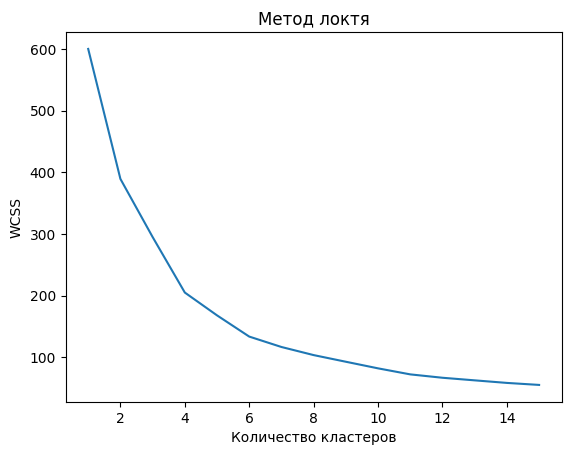

In [45]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 16):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 16), wcss)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

По графику видно, что по методу локтя оптимальное колличество кластеров равно 6

# Обучаем модель кластеризации

In [50]:
kmeans = KMeans(n_clusters=6, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=6, n_init=10, random_state=42)


# Предсказываем кластеры и визуализируем результаты

In [51]:
clusters = kmeans.predict(X)

data_copy['cluster'] = clusters
data_copy.head()


,Age,Annual Income (k$),Spending Score (1-100),cluster
0,19,15,39,4
1,21,15,81,4
2,20,16,6,5
3,23,16,77,4
4,31,17,40,5


# Визуализация результатов

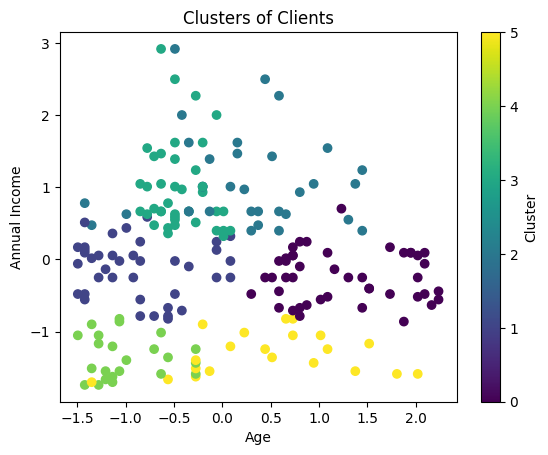

In [52]:
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

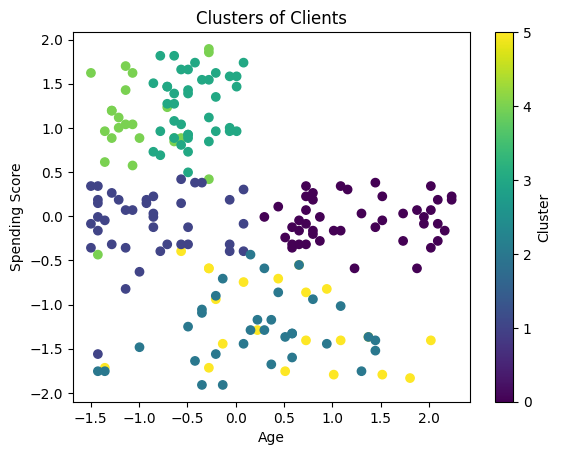

In [55]:
plt.scatter(X[:, 0], X[:, 2], c=clusters, cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

# Группируем по кластерам и анализируем средние значения в каждом кластере

In [56]:
cluster_groups = data_copy.groupby('cluster')

cluster_groups.mean()

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


# Интерпритация полученных данных по целевым аудиториям
* Кластер 0: Пожилые клиенты с умеренным доходом и средними тратами — стабильные, но не самые прибыльные.
* Кластер 1: Молодые клиенты с высоким доходом, но низкими тратами — потенциал роста при вовлечении.
* Кластер 2: Зрелые клиенты с высоким доходом, но крайне низкими тратами — малоактивны, нецелевая группа.
* Кластер 3: Молодые, обеспеченные и активные покупатели — ключевая целевая аудитория.
*Кластер 4: Очень молодые с низким доходом, но высокими тратами — активны, но финансово нестабильны.
* Кластер 5: Зрелые клиенты с низким доходом и минимальными тратами — наименее прибыльная группа.

Проверим распределение гендера посетителей по кластерам


In [64]:
data['cluster'] = clusters

gender = data.groupby('cluster')['Genre'].value_counts(normalize=True).unstack(fill_value=0)
print(gender)

Genre      Female      Male
cluster                    
0        0.577778  0.422222
1        0.641026  0.358974
2        0.424242  0.575758
3        0.538462  0.461538
4        0.565217  0.434783
5        0.619048  0.380952
